In [ ]:
import requests
import pandas as pd
import time
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
base_url="https://api.worldbank.org/v2/countries/all/indicators/"

In [ ]:
all_data = []
page=1
session=requests.session()
indicators = {
    "GDP Growth (%)": "NY.GDP.MKTP.KD.ZG",
    "Agriculture Growth (%)": "NV.AGR.TOTL.KD.ZG",
    "Industry Growth (%)": "NV.IND.TOTL.KD.ZG",
    "Manufacturing Growth (%)": "NV.IND.MANF.KD.ZG",
    "Services Growth (%)": "NV.SRV.TOTL.KD.ZG",
    "Exports Growth (%)": "NE.EXP.GNFS.KD.ZG",
    "Imports Growth (%)": "NE.IMP.GNFS.KD.ZG",
    "Foreign Direct Investment (% of GDP)": "BX.KLT.DINV.WD.GD.ZS",
    "Final Consumption Growth (%)": "NE.CON.TOTL.KD.ZG",
    "Gross Capital Formation Growth (%)": "NE.GDI.TOTL.KD.ZG",
    "Unemployment Rate (%)": "SL.UEM.TOTL.ZS",
    "GDP per person employed ($, PPP)": "SL.GDP.PCAP.EM.KD",
    "Inflation (CPI)": "FP.CPI.TOTL"
}

In [ ]:
for indicator_name,indicator_code in indicators.items():
  page=1
  print(f"fetching data for {indicator_name}")
  while True:
    try:
      print(f"fetching page{page}...")
      response=session.get(base_url+indicator_code,params={"format":"json","per_page":50,"page":page},timeout=10)
      data=response.json()
      if len(data)<2 or not data[1] :
        break
      for item in data[1]:
        if item["value"] is not None:
          all_data.append({
            "Country":item["country"]["value"],
            "Year":int(item["date"]),
            "Value":float(item["value"]),
            "indicator":indicator_name
          })
      page+=1
      '''time.sleep(1)'''
    except Exception as e:
      print(f"Error fetching data for {indicator_name}: {e}")
      break
session.close()

fetching data for GDP Growth (%)
fetching page1...
fetching page2...
fetching page3...
fetching page4...
fetching page5...
fetching page6...
fetching page7...
fetching page8...
fetching page9...
fetching page10...
fetching page11...
fetching page12...
fetching page13...
fetching page14...
fetching page15...
fetching page16...
fetching page17...
fetching page18...
fetching page19...
fetching page20...
fetching page21...
fetching page22...
fetching page23...
fetching page24...
fetching page25...
fetching page26...
fetching page27...
fetching page28...
fetching page29...
fetching page30...
fetching page31...
fetching page32...
fetching page33...
fetching page34...
fetching page35...
fetching page36...
fetching page37...
fetching page38...
fetching page39...
fetching page40...
fetching page41...
fetching page42...
fetching page43...
fetching page44...
fetching page45...
fetching page46...
fetching page47...
fetching page48...
fetching page49...
fetching page50...
fetching page51...
fetchin

In [ ]:
df=pd.DataFrame(all_data)
df.head()

,Country,Year,Value,indicator
0,Africa Eastern and Southern,2023,2.320138,GDP Growth (%)
1,Africa Eastern and Southern,2022,3.553878,GDP Growth (%)
2,Africa Eastern and Southern,2021,4.576393,GDP Growth (%)
3,Africa Eastern and Southern,2020,-2.864293,GDP Growth (%)
4,Africa Eastern and Southern,2019,2.194319,GDP Growth (%)


In [ ]:
df_pivot=df.pivot_table(index=["Country","Year"],columns="indicator",values="Value").reset_index()
df_pivot=df_pivot.loc[:,~df_pivot.columns.duplicated()]

In [ ]:
df_pivot.info()
df_pivot.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14438 entries, 0 to 14437
Data columns (total 15 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Country                               14438 non-null  object 
 1   Year                                  14438 non-null  int64  
 2   Agriculture Growth (%)                10022 non-null  float64
 3   Exports Growth (%)                    8654 non-null   float64
 4   Final Consumption Growth (%)          8675 non-null   float64
 5   Foreign Direct Investment (% of GDP)  11520 non-null  float64
 6   GDP Growth (%)                        13883 non-null  float64
 7   GDP per person employed ($, PPP)      7361 non-null   float64
 8   Gross Capital Formation Growth (%)    7828 non-null   float64
 9   Imports Growth (%)                    8678 non-null   float64
 10  Industry Growth (%)                   9666 non-null   float64
 11  Inflation (CPI)

indicator,Year,Agriculture Growth (%),Exports Growth (%),Final Consumption Growth (%),Foreign Direct Investment (% of GDP),GDP Growth (%),"GDP per person employed ($, PPP)",Gross Capital Formation Growth (%),Imports Growth (%),Industry Growth (%),Inflation (CPI),Manufacturing Growth (%),Services Growth (%),Unemployment Rate (%)
count,14438.000000,10022.000000,8654.000000,8675.000000,11520.000000,1.388300e+04,7361.000000,7828.000000,8678.000000,9666.000000,8.904000e+03,8327.000000,9036.000000,6133.000000
mean,1994.463776,2.605208,5.985076,3.743242,4.798658,7.238997e+03,46108.740806,5.838121,5.828325,3.833575,9.318240e+01,3.754128,4.140894,7.900750
std,17.668291,10.692762,20.418488,7.819728,39.884703,8.525103e+05,44631.214358,32.099466,14.658110,9.876256,6.847110e+02,15.359513,6.675144,5.889701
min,1960.000000,-65.959443,-96.364419,-40.868215,-1303.108267,-6.404711e+01,1150.461179,-938.995687,-94.700000,-80.296779,3.546558e-14,-79.646665,-100.000000,0.091000
25%,1980.000000,-0.706881,0.000000,1.533513,0.446734,1.405947e+00,12060.704035,-2.664951,-0.755265,0.070251,1.850354e+01,-0.123599,1.856645,3.857000
50%,1996.000000,2.720079,5.133382,3.568868,1.515728,3.809583e+00,32419.624966,4.566718,5.403719,3.713856,6.608705e+01,3.526896,4.094118,6.300000
75%,2010.000000,5.483132,10.489979,5.783444,3.571305,6.119111e+00,64995.390211,11.844222,11.709008,7.389401,1.037901e+02,7.238423,6.486422,10.390000
max,2023.000000,547.393678,1045.449294,393.570492,1709.827232,1.004480e+08,316456.423797,1005.916401,328.685257,196.074936,3.879656e+04,913.135187,181.844723,37.976002


In [ ]:
print(df_pivot[df_pivot["GDP Growth (%)"]>100])

indicator            Country  Year  Agriculture Growth (%)  \
3714       Equatorial Guinea  1997                     NaN   
7615                 Liberia  1997                     NaN   
10098                   Oman  1965                     NaN   

indicator  Exports Growth (%)  Final Consumption Growth (%)  \
3714                      NaN                           NaN   
7615                      NaN                           NaN   
10098                     NaN                           NaN   

indicator  Foreign Direct Investment (% of GDP)  GDP Growth (%)  \
3714                                  12.083869    1.499730e+02   
7615                                  72.260899    1.062798e+02   
10098                                       NaN    1.004480e+08   

indicator  GDP per person employed ($, PPP)  \
3714                           22383.025560   
7615                            2599.072972   
10098                                   NaN   

indicator  Gross Capital Formation Growt

In [ ]:
print("="*50)
print("Data Quality Assessment")
print("="*50)
print("\nData Structure:")
print(f"Total countries: {df_pivot['Country'].nunique()}")
print(f"Time range: {df_pivot['Year'].min()} to {df_pivot['Year'].max()}")
print(f"Available indicators: {len(indicators)}")

Data Quality Assessment

Data Structure:
Total countries: 264
Time range: 1960 to 2023
Available indicators: 13


**Visualising and Handling Missing values**

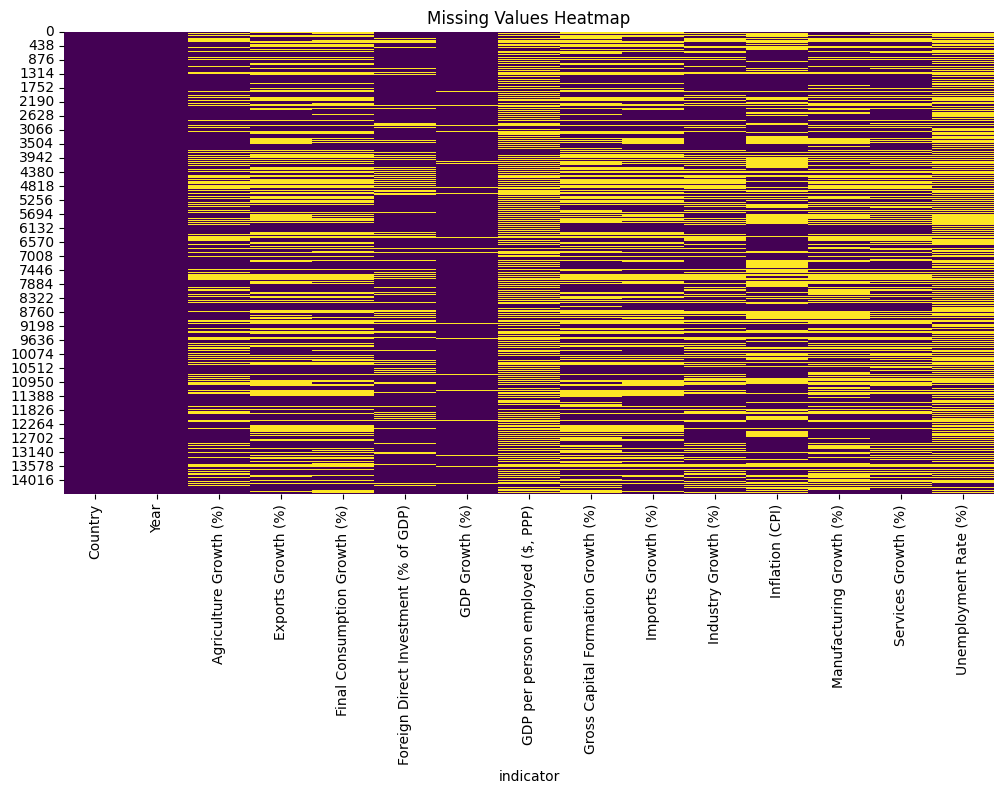

In [ ]:
#visualisig missing data(before imputation) using heatmap
plt.figure(figsize=(12,6))
sns.heatmap(df_pivot.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

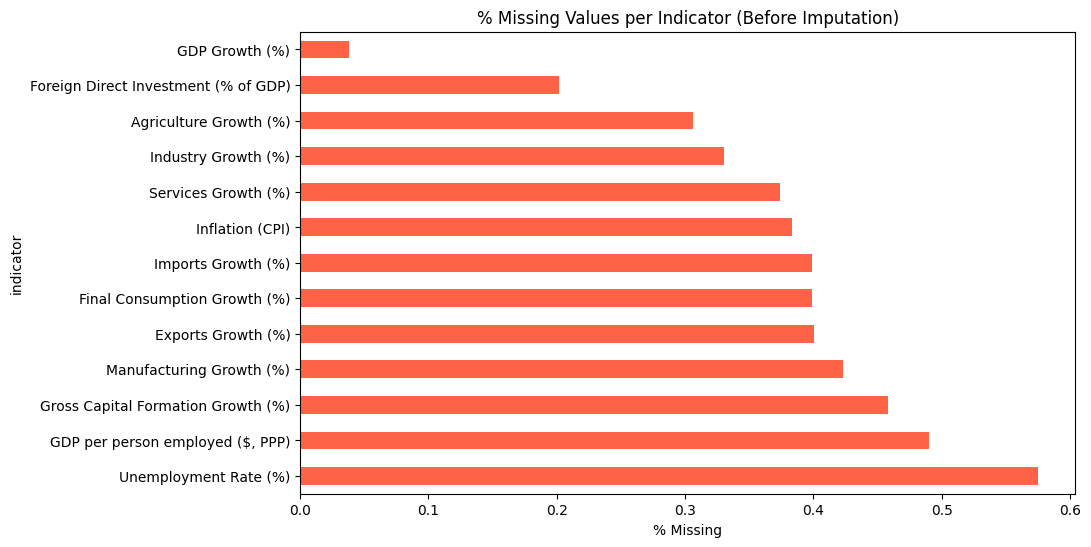

In [ ]:
#visualising missing data(before imputation) using barmap
missing_percentage = df_pivot.isnull().mean().sort_values(ascending=False)
missing_percentage[missing_percentage > 0].plot(kind='barh', figsize=(10, 6), color='tomato')
plt.title("% Missing Values per Indicator (Before Imputation)")
plt.xlabel("% Missing")
plt.show()

In [ ]:
#missing values percentage
missing_values = df_pivot.isnull().sum().sort_values(ascending=False)
missing_df=pd.DataFrame({
    "Missing Values":missing_values,
    "Missing Percentage":missing_percentage
})
print("Missing Values per Indicator:\n", missing_df)




Missing Values per Indicator:
                                       Missing Values  Missing Percentage
indicator                                                               
Unemployment Rate (%)                           8305            0.575218
GDP per person employed ($, PPP)                7077            0.490165
Gross Capital Formation Growth (%)              6610            0.457820
Manufacturing Growth (%)                        6111            0.423258
Exports Growth (%)                              5784            0.400610
Final Consumption Growth (%)                    5763            0.399155
Imports Growth (%)                              5760            0.398947
Inflation (CPI)                                 5534            0.383294
Services Growth (%)                             5402            0.374152
Industry Growth (%)                             4772            0.330517
Agriculture Growth (%)                          4416            0.305860
Foreign Direct Inves

In [ ]:
#Handling missing values
if "Unemployment Rate (%)" and "GDP per person employed ($, PPP)" in df_pivot.columns:
  df_pivot=df_pivot.drop(columns=["Unemployment Rate (%)","GDP per person employed ($, PPP)"])
df_pivot = df_pivot.sort_values(by=["Country", "Year"])
df_pivot = df_pivot.groupby("Country").apply(lambda group: group.ffill().bfill()).reset_index(drop=True)
fill_year_median = [
    "Agriculture Growth (%)", "Industry Growth (%)", "Services Growth (%)",
    "Foreign Direct Investment (% of GDP)"
]
for col in fill_year_median:
    df_pivot[col] = df_pivot.groupby("Year")[col].transform(lambda x: x.fillna(x.median()))

# Impute Inflation (CPI) using median per year (cross-country trends)
df_pivot["Inflation (CPI)"] = df_pivot.groupby("Year")["Inflation (CPI)"].transform(lambda x: x.fillna(x.median()))

# Exports, Imports, Final Consumption, Gross Capital, Manufacturing — per year median
median_year_impute = [
    "Exports Growth (%)", "Imports Growth (%)", "Final Consumption Growth (%)",
    "Gross Capital Formation Growth (%)", "Manufacturing Growth (%)"
]
for col in median_year_impute:
    df_pivot[col] = df_pivot.groupby("Year")[col].transform(lambda x: x.fillna(x.median()))

<ipython-input-12-0baac366dea6>:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_pivot = df_pivot.groupby("Country").apply(lambda group: group.ffill().bfill()).reset_index(drop=True)


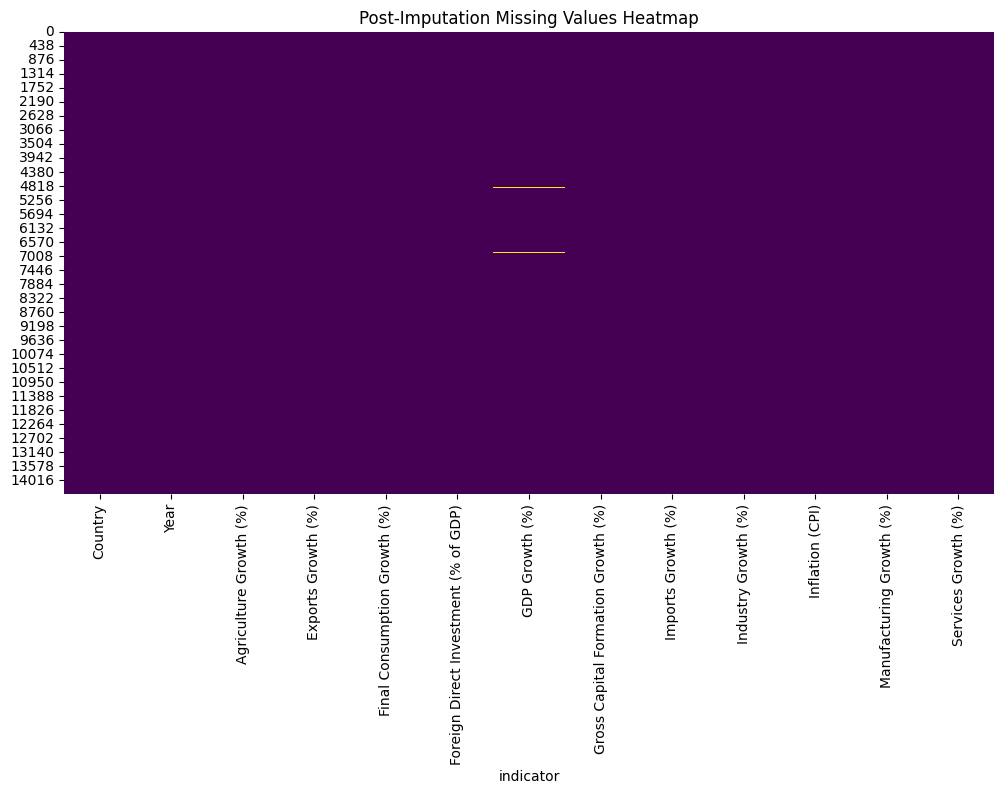

In [ ]:
#Visualize Missing Values(After Imputation) using heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(df_pivot.isnull(), cbar=False, cmap="viridis")
plt.title("Post-Imputation Missing Values Heatmap")
plt.show()


**Detecting and Handling Outliers**

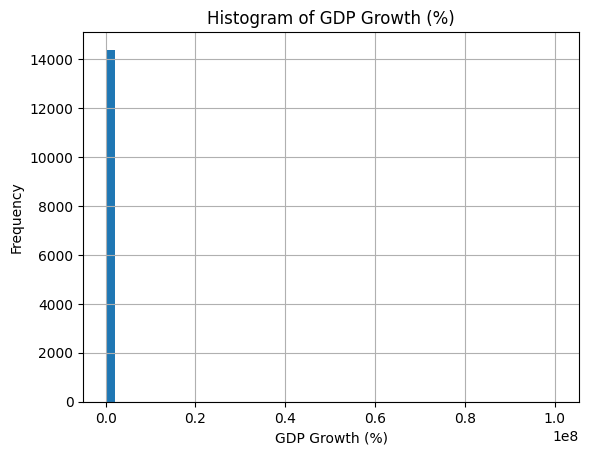

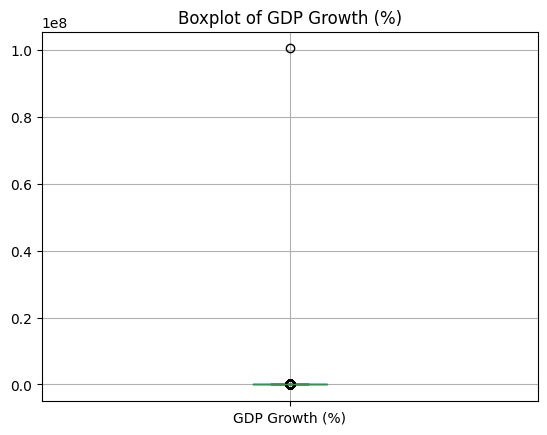

In [ ]:
# Box plot for spotting outliers
df_pivot["GDP Growth (%)"].hist(bins=50)
plt.title("Histogram of GDP Growth (%)")
plt.xlabel("GDP Growth (%)")
plt.ylabel("Frequency")
plt.show()

df_pivot.boxplot(column="GDP Growth (%)")
plt.title("Boxplot of GDP Growth (%)")
plt.show()


In [ ]:
print(df_pivot['GDP Growth (%)'].mean())
print(df_pivot['GDP Growth (%)'].median())

6985.988391206069
3.802815444783115


In [ ]:
df_pivot=df_pivot[df_pivot["GDP Growth (%)"]<1000]

In [ ]:
import numpy as np
numeric_cols = df_pivot.select_dtypes(include=[np.number]).columns.tolist()
def detect_outliers_iqr(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]

    return outliers, lower_bound, upper_bound

for col in numeric_cols:
    outliers, low, high = detect_outliers_iqr(df_pivot, col)
    print(f"{col}: {len(outliers)} outliers")
    print(f"Bounds: {low:.2f} to {high:.2f}")
    print(outliers[['Country', 'Year', col]].head())
    print("=" * 50)


Year: 0 outliers
Bounds: 1935.00 to 2055.00
Empty DataFrame
Columns: [Country, Year, Year]
Index: []
Agriculture Growth (%): 1493 outliers
Bounds: -9.64 to 14.18
indicator      Country  Year  Agriculture Growth (%)
13         Afghanistan  2004              -22.236356
14         Afghanistan  2005               17.698103
16         Afghanistan  2007               14.700446
17         Afghanistan  2008              -14.916330
18         Afghanistan  2009               44.562955
Exports Growth (%): 1484 outliers
Bounds: -13.03 to 23.34
indicator                      Country  Year  Exports Growth (%)
71         Africa Eastern and Southern  1999           27.778448
83         Africa Eastern and Southern  2011          -38.612211
84         Africa Eastern and Southern  2012          -14.758262
159                            Albania  1980          -18.274438
160                            Albania  1981          -18.274438
Final Consumption Growth (%): 1484 outliers
Bounds: -3.73 to 10.90
indic

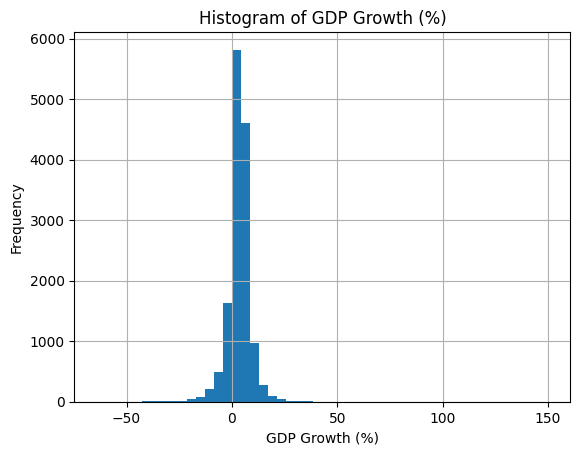

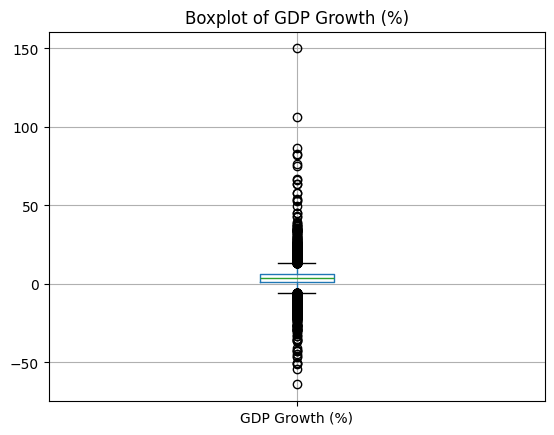

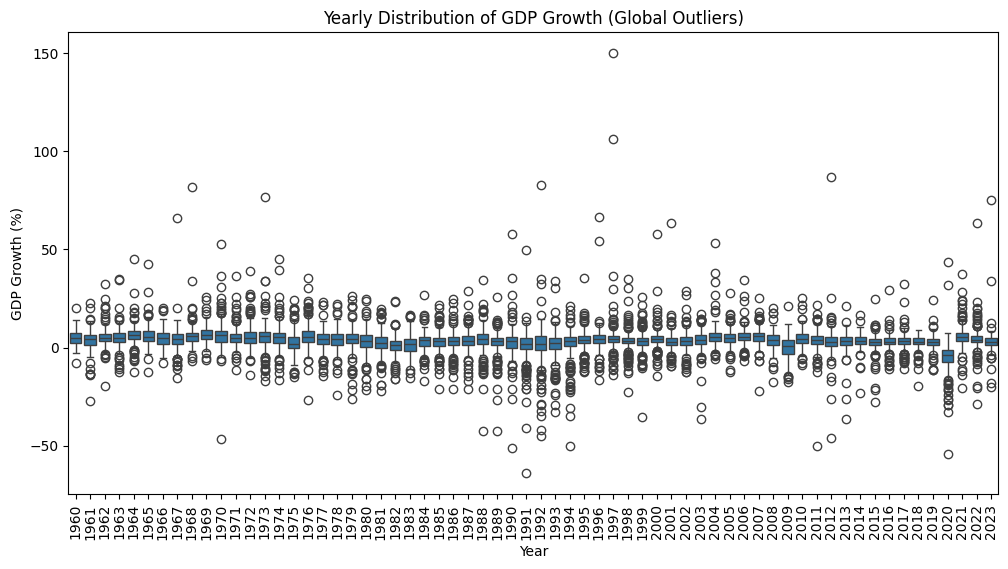

In [ ]:
df_pivot["GDP Growth (%)"].hist(bins=50)
plt.title("Histogram of GDP Growth (%)")
plt.xlabel("GDP Growth (%)")
plt.ylabel("Frequency")
plt.show()

# Box plot - Great for spotting outliers
df_pivot.boxplot(column="GDP Growth (%)")
plt.title("Boxplot of GDP Growth (%)")
plt.show()

# Boxplot of GDP growth by year
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_pivot, x='Year', y='GDP Growth (%)')
plt.xticks(rotation=90)
plt.title('Yearly Distribution of GDP Growth (Global Outliers)')
plt.show()


In [ ]:
# Remove extreme outliers using IQR method
'''def remove_outliers_iqr(df, columns):
    for col in columns:
        if df[col].isnull().all():
            continue
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df = df[(df[col] >= lower) & (df[col] <= upper)]
    return df,Q1,Q3,IQR,lower,upper

numeric_cols = df_pivot.select_dtypes(include=[np.number]).columns.tolist()
df_pivot,Q1,Q3,IQR,lower,upper = remove_outliers_iqr(df_pivot, numeric_cols)
print(Q1)
print(Q3)
print(IQR)
print(lower)
print(upper)
'''

'def remove_outliers_iqr(df, columns):\n    for col in columns:\n        if df[col].isnull().all():\n            continue\n        Q1 = df[col].quantile(0.25)\n        Q3 = df[col].quantile(0.75)\n        IQR = Q3 - Q1\n        lower = Q1 - 1.5 * IQR\n        upper = Q3 + 1.5 * IQR\n        df = df[(df[col] >= lower) & (df[col] <= upper)]\n    return df,Q1,Q3,IQR,lower,upper\n\nnumeric_cols = df_pivot.select_dtypes(include=[np.number]).columns.tolist()\ndf_pivot,Q1,Q3,IQR,lower,upper = remove_outliers_iqr(df_pivot, numeric_cols)\nprint(Q1)\nprint(Q3)\nprint(IQR)\nprint(lower)\nprint(upper)\n'

In [ ]:
# Define custom lower and upper bounds for each indicator
custom_bounds = {
    "GDP Growth (%)": (-60, 150),
    "Inflation (CPI)": (0, 200),
    "Agriculture Growth (%)": (-50, 100),
    "Industry Growth (%)": (-50, 100),
    "Manufacturing Growth (%)": (-50, 100),
    "Services Growth (%)": (-50, 100),
    "Exports Growth (%)": (-100, 150),
    "Imports Growth (%)": (-100, 150),
    "Foreign Direct Investment (% of GDP)": (-50, 100),
    "Final Consumption Growth (%)": (-100, 150),
    "Gross Capital Formation Growth (%)": (-100, 150)
}

# Apply filters for each column based on specified bounds
for col, (low, high) in custom_bounds.items():
    if col in df_pivot.columns:
        df_pivot = df_pivot[(df_pivot[col] >= low) & (df_pivot[col] <= high)]

# Optional: Check remaining shape
print("Shape after custom outlier removal:", df_pivot.shape)


Shape after custom outlier removal: (13904, 13)


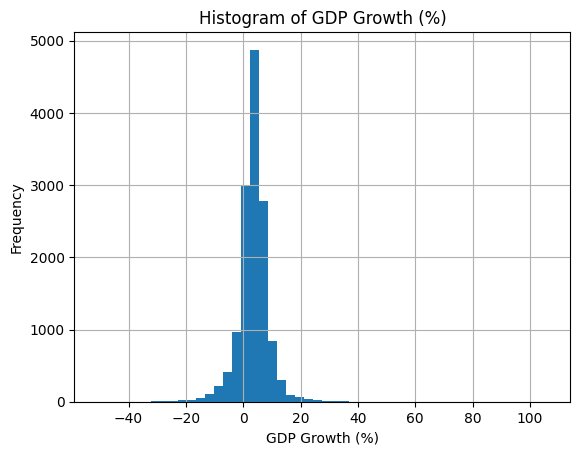

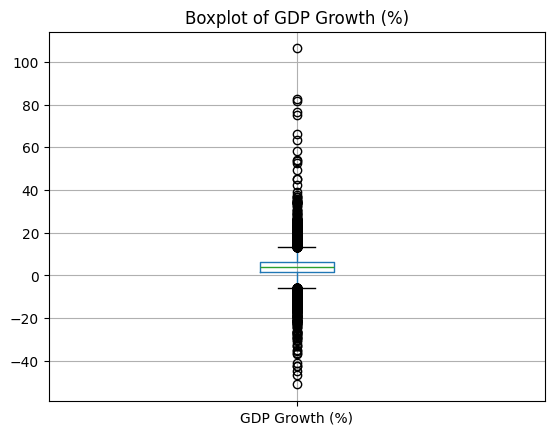

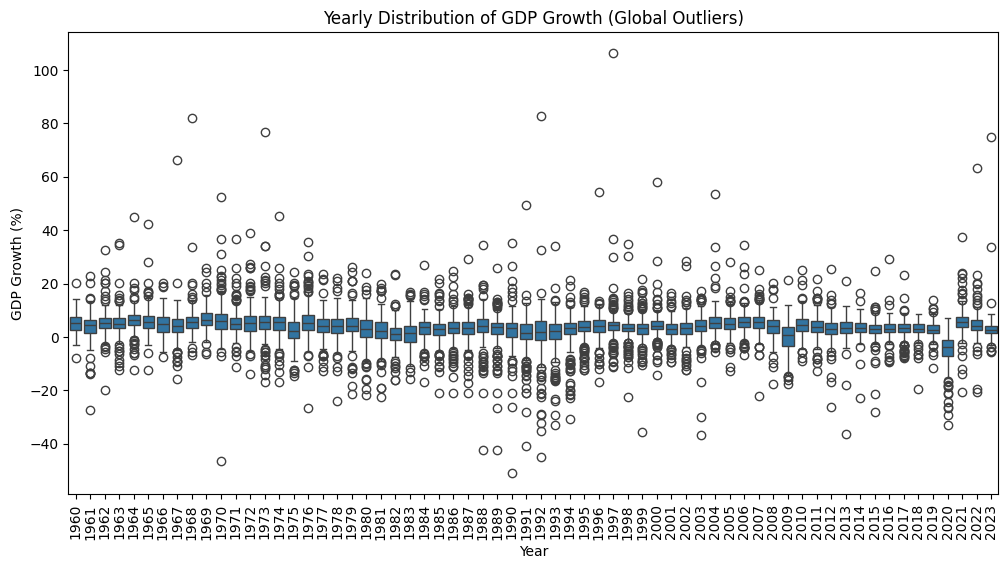

In [ ]:

df_pivot["GDP Growth (%)"].hist(bins=50)
plt.title("Histogram of GDP Growth (%)")
plt.xlabel("GDP Growth (%)")
plt.ylabel("Frequency")
plt.show()

# Box plot - Great for spotting outliers
df_pivot.boxplot(column="GDP Growth (%)")
plt.title("Boxplot of GDP Growth (%)")
plt.show()

# Boxplot of GDP growth by year
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_pivot, x='Year', y='GDP Growth (%)')
plt.xticks(rotation=90)
plt.title('Yearly Distribution of GDP Growth (Global Outliers)')
plt.show()


In [ ]:
print(df_pivot.isnull().mean()*100)

indicator
Country                                 0.0
Year                                    0.0
Agriculture Growth (%)                  0.0
Exports Growth (%)                      0.0
Final Consumption Growth (%)            0.0
Foreign Direct Investment (% of GDP)    0.0
GDP Growth (%)                          0.0
Gross Capital Formation Growth (%)      0.0
Imports Growth (%)                      0.0
Industry Growth (%)                     0.0
Inflation (CPI)                         0.0
Manufacturing Growth (%)                0.0
Services Growth (%)                     0.0
dtype: float64


**Trend Analysis**


Global Economic Trends Analysis


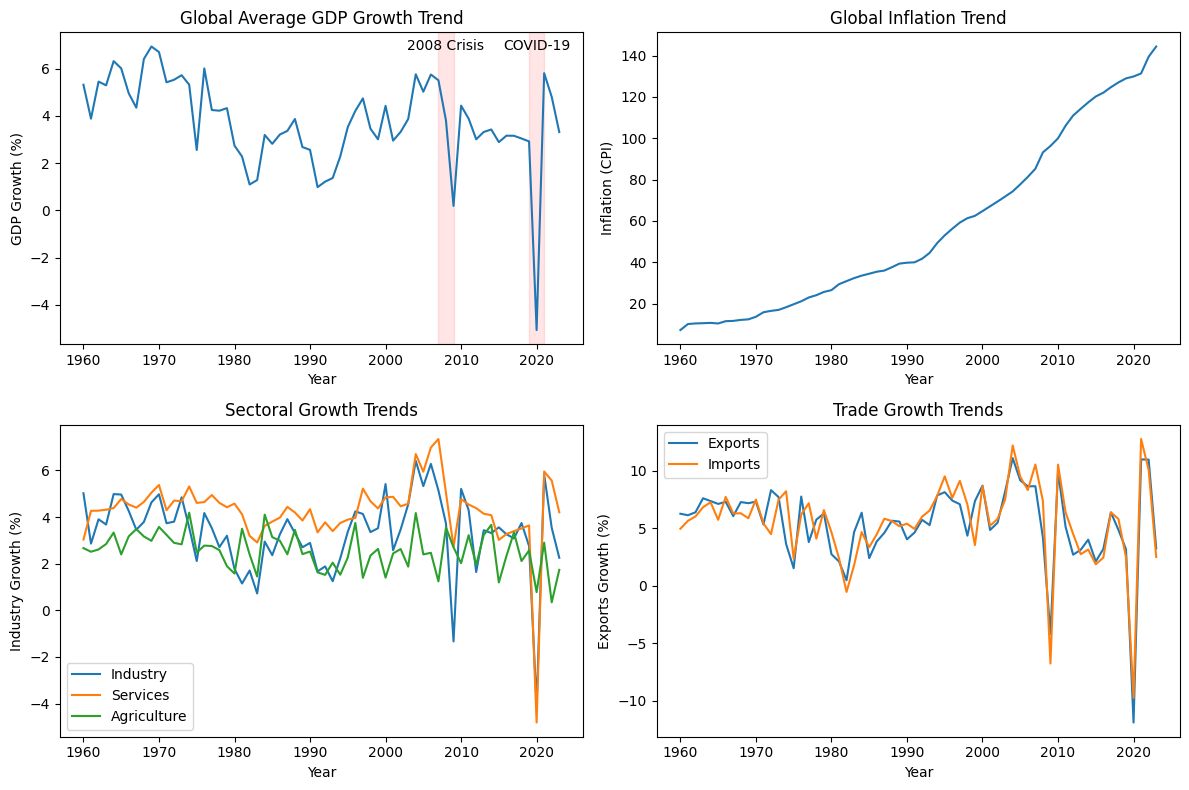

In [ ]:
print("\n" + "="*50)
print("Global Economic Trends Analysis")
print("="*50)

df_pivot['Decade'] = (df_pivot['Year'] // 10) * 10

global_avg = df_pivot.groupby('Year').mean(numeric_only=True).reset_index()

crisis_periods = {
    '2008 Crisis': (2007, 2009),
    'COVID-19': (2019, 2021)
}
plt.figure(figsize=(12,8))
plt.subplot(2, 2, 1)
ax=sns.lineplot(data=global_avg, x='Year', y='GDP Growth (%)')
plt.title('Global Average GDP Growth Trend')
for name, (start, end) in crisis_periods.items():
    ax.axvspan(start, end, color='red', alpha=0.1)
    ax.text((start+end)/2, ax.get_ylim()[1]*0.9, name, ha='center')

plt.subplot(2, 2, 2)
sns.lineplot(data=global_avg, x='Year', y='Inflation (CPI)')
plt.title('Global Inflation Trend')

plt.subplot(2, 2, 3)
sns.lineplot(data=global_avg, x='Year', y='Industry Growth (%)', label='Industry')
sns.lineplot(data=global_avg, x='Year', y='Services Growth (%)', label='Services')
sns.lineplot(data=global_avg, x='Year', y='Agriculture Growth (%)', label='Agriculture')
plt.title('Sectoral Growth Trends')
plt.legend()

plt.subplot(2, 2, 4)
sns.lineplot(data=global_avg, x='Year', y='Exports Growth (%)', label='Exports')
sns.lineplot(data=global_avg, x='Year', y='Imports Growth (%)', label='Imports')
plt.title('Trade Growth Trends')
plt.legend()

plt.tight_layout()
plt.show()

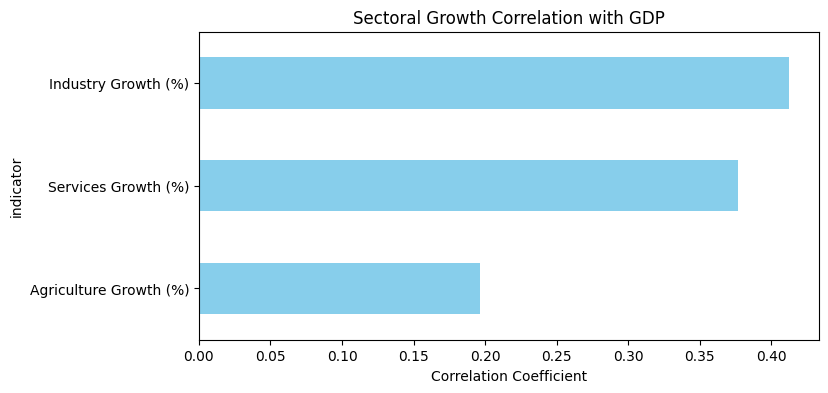

In [ ]:
# Compare sector growth correlations with GDP
sector_columns = ['Agriculture Growth (%)', 'Industry Growth (%)', 'Services Growth (%)']
sector_corr = df_pivot[sector_columns + ['GDP Growth (%)']].corr()['GDP Growth (%)'].drop('GDP Growth (%)')

plt.figure(figsize=(8, 4))
sector_corr.sort_values().plot(kind='barh', color='skyblue')
plt.title('Sectoral Growth Correlation with GDP')
plt.xlabel('Correlation Coefficient')
plt.show()

<ipython-input-26-c60f5965c3ec>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_gdp, y="Country", x="GDP Growth (%)", palette="coolwarm")


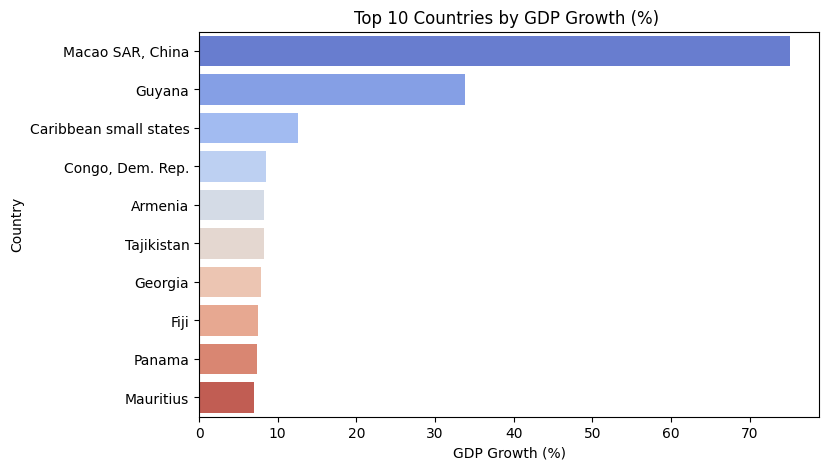

In [ ]:
# Top 10 countries by GDP Growth
top_gdp = df_pivot[df_pivot["Year"] == 2023][["Country", "GDP Growth (%)"]].dropna().sort_values(by="GDP Growth (%)", ascending=False).head(10)

plt.figure(figsize=(8, 5))
sns.barplot(data=top_gdp, y="Country", x="GDP Growth (%)", palette="coolwarm")
plt.title("Top 10 Countries by GDP Growth (%) ")
plt.show()



Correlation Analysis


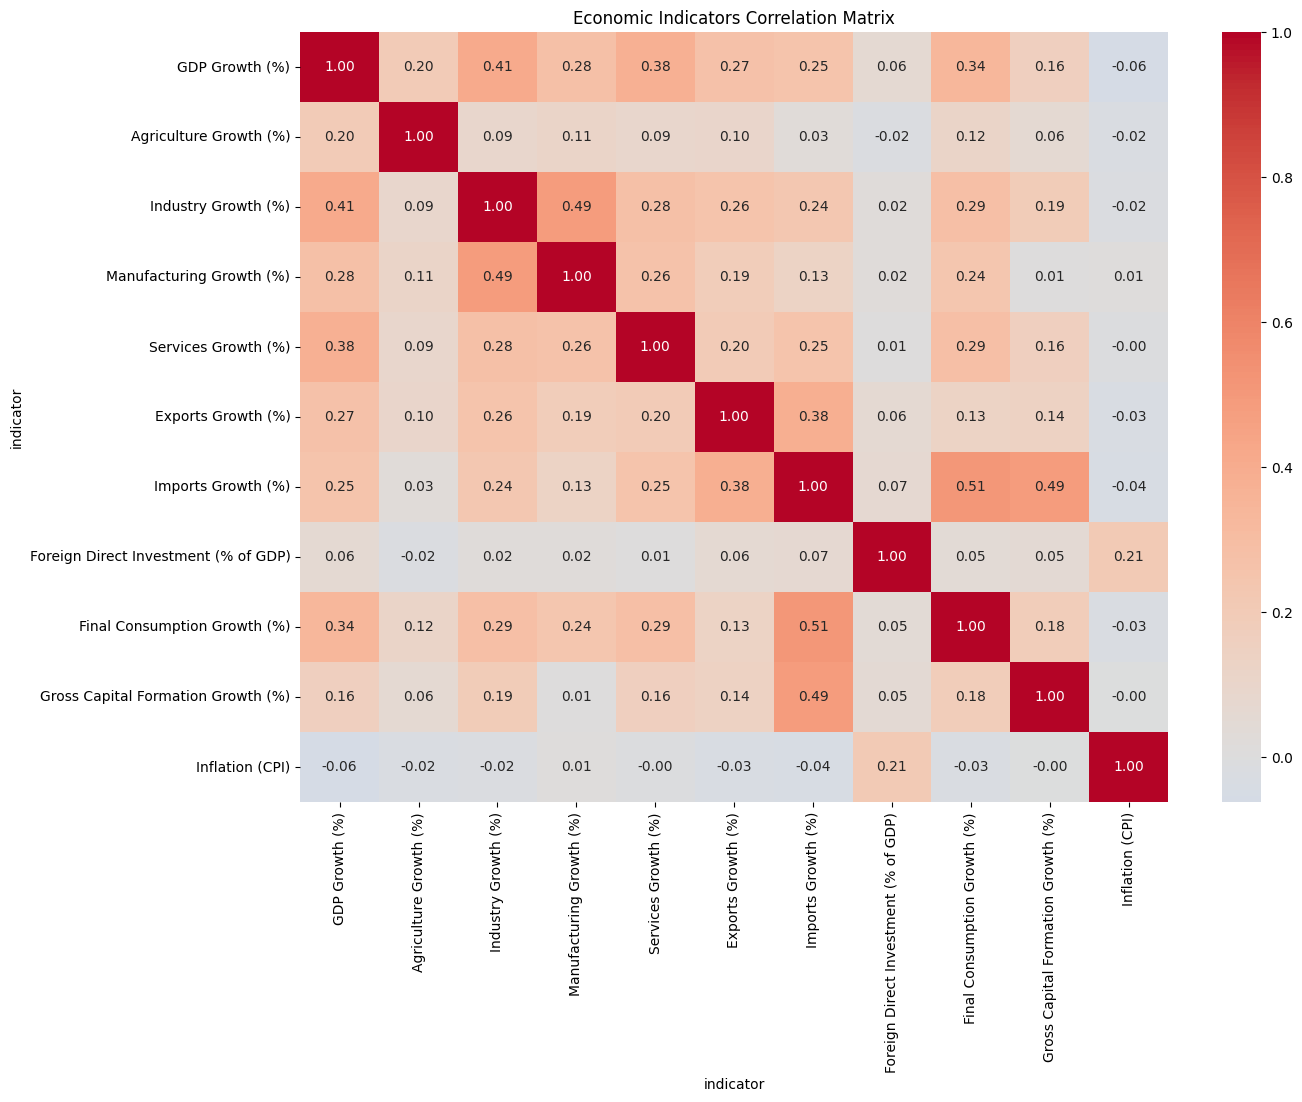


Top Positive Correlations with GDP Growth:
indicator
Industry Growth (%)             0.412611
Services Growth (%)             0.376548
Final Consumption Growth (%)    0.336530
Manufacturing Growth (%)        0.278558
Exports Growth (%)              0.269908
Name: GDP Growth (%), dtype: float64

Top Negative Correlations with GDP Growth:
indicator
Imports Growth (%)                      0.249077
Agriculture Growth (%)                  0.196421
Gross Capital Formation Growth (%)      0.164761
Foreign Direct Investment (% of GDP)    0.060132
Inflation (CPI)                        -0.062368
Name: GDP Growth (%), dtype: float64


In [ ]:
## 4. Correlation Analysis
print("\n" + "="*50)
print("Correlation Analysis")
print("="*50)

# Calculate correlations
if "Unemployment Rate (%)" and "GDP per person employed ($, PPP)" in indicators:
  del indicators["Unemployment Rate (%)"]
  del indicators["GDP per person employed ($, PPP)"]
corr_matrix = df_pivot[list(indicators.keys())].corr()

# Plot heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt=".2f")
plt.title('Economic Indicators Correlation Matrix')
plt.show()

# Top correlations with GDP growth
gdp_corrs = corr_matrix['GDP Growth (%)'].sort_values(ascending=False)
print("\nTop Positive Correlations with GDP Growth:")
print(gdp_corrs[1:6])  # Skip GDP's correlation with itself
print("\nTop Negative Correlations with GDP Growth:")
print(gdp_corrs[-5:])

In [ ]:
import plotly.express as px
import plotly.graph_objects as go
df_latest = df_pivot[df_pivot["Year"] == 2019]

fig = px.choropleth(
    df_latest,
    locations="Country",
    locationmode="country names",
    color="GDP Growth (%)",
    hover_name="Country",
    color_continuous_scale="Viridis",
    title=f"GDP Growth (%) by Country ",
    range_color=[-10, 15]
)

fig.update_layout(
    geo=dict(showframe=False, showcoastlines=False),
    margin=dict(l=0, r=0, t=50, b=0)
)

fig.show()


In [ ]:
df_pivot.to_csv("WDI_data.csv", index=False)